## Archivo de comparación de diferentes modelos de machine learning usando solo metadatos

## Configuración de entorno

### Librerias

In [1]:
# ------------------------------------------------------------------------------
# 1.1 IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
import os
import sys
import random
import warnings

# Manipulación de Datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Clásico y Métricas
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

# Gradient Boosting (Modelos Tabulares Potentes)
# Nota: Asegúrate de tener instalados: pip install lightgbm catboost
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

# Deep Learning (PyTorch para el MLP)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 100) # Para ver todas las columnas de metadatos
warnings.filterwarnings('ignore') # Ignorar warnings molestos de versiones

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


### Reproducibilidad

In [2]:
# ------------------------------------------------------------------------------
# 1.2 FIJAR SEMILLAS (REPRODUCIBILIDAD)
# ------------------------------------------------------------------------------
SEED = 42

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Semillas fijadas en: {seed}")

seed_everything(SEED)

✅ Semillas fijadas en: 42


### Rutas y hardware

In [3]:
# ------------------------------------------------------------------------------
# 1.3 RUTAS Y HARDWARE
# ------------------------------------------------------------------------------

# --- RUTAS ---
# Asumiendo que el notebook está en una subcarpeta (ej. /notebooks o /code)
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, 'data')

TRAIN_CSV = os.path.join(data_dir, 'new-train-metadata.csv')
TEST_CSV  = os.path.join(data_dir, 'students-test-metadata.csv')

# Verificar existencia
if os.path.exists(TRAIN_CSV) and os.path.exists(TEST_CSV):
    print(f"✅ Datos encontrados en: {data_dir}")
else:
    print(f"❌ ERROR: No se encuentran los CSV en {data_dir}")
    print("Verifica que la carpeta 'data' esté en el directorio padre.")

# --- HARDWARE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dispositivo para MLP: {DEVICE}")

if str(DEVICE) == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Datos encontrados en: /home/jorge/Documentos/Deep/ISIC_DL/data
✅ Dispositivo para MLP: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Análisis de Variables y Estrategia de Limpieza

Para construir un modelo robusto y evitar errores en la fase de inferencia (submission), hemos analizado las discrepancias entre el conjunto de entrenamiento (`new-train-metadata.csv`) y el conjunto de test (`students-test-metadata.csv`).

A continuación, se clasifican las variables disponibles y se define la estrategia de exclusión para evitar **Data Leakage** y **Feature Mismatch**.

### La Variable Objetivo (Target)

* **`target`**: Variable binaria.
    * `0`: Benigno.
    * `1`: Maligno.

> **Nota:** Esta columna solo existe en Train. Es lo que nuestro modelo intentará aprender.

### Variables Predictoras (Features "Seguras")

Estas variables existen tanto en Train como en Test y representan información disponible en el momento de la consulta médica (antes de la biopsia). Serán las entradas ($X$) de nuestros modelos (LightGBM, CatBoost, MLP).

#### 👤 Demográficas y Clínicas

| Variable | Descripción | Importancia Esperada |
| :--- | :--- | :--- |
| **`age_approx`** | Edad aproximada del paciente. | **Alta**. El riesgo de cáncer acumulativo aumenta con la edad. |
| **`sex`** | Sexo biológico. | **Media**. Existen diferencias de incidencia por sexo. |
| **`anatom_site_general`** | Ubicación corporal (ej. cabeza/cuello). | **Alta**. Zonas expuestas al sol tienen mayor prevalencia. |
| **`clin_size_long_diam_mm`** | Diámetro mayor de la lesión (mm). | **Crítica**. El tamaño es uno de los criterios ABCD del melanoma. |

#### 🔬 Física y Colorimetría (Sistema TBP)

El sistema de Fotografía Corporal Total calcula métricas automáticas sobre el "tile" (recorte) de la imagen.

* **Color (Espacio LAB):** Variables como `tbp_lv_L` (Luminancia), `tbp_lv_A` (Eje Rojo-Verde), `tbp_lv_B` (Eje Amarillo-Azul).
* **Contraste (Deltas):** Variables cruciales como `tbp_lv_deltaLBnorm`. Miden cuánto destaca la lesión respecto a la piel sana circundante ("Patito Feo").
* **Forma y Geometría:**
    * `tbp_lv_areaMM2`: Área.
    * `tbp_lv_perimeterMM`: Perímetro.
    * `tbp_lv_area_perim_ratio`: Indicador de bordes irregulares.
    * `tbp_lv_eccentricity`: Qué tan alargada/elíptica es la lesión.
* **Textura/Irregularidad:** `tbp_lv_color_std_mean`, `tbp_lv_radial_color_std_max`.

### Variables Excluidas (Drop List)

Hemos identificado tres categorías de variables que deben ser eliminadas del entrenamiento. Incluirlas provocaría que el modelo falle al evaluar el Test Set o que aprenda atajos ilegales ("hacer trampa").

#### 🚨 A. Data Leakage (Información del Futuro)
Estas variables contienen información clínica obtenida **después** de realizar una biopsia o diagnóstico patológico. No están disponibles cuando el paciente llega a la consulta.

* **Diagnósticos:** `iddx_full`, `iddx_1` (ej. "Melanoma"), `iddx_2`, `iddx_3`, `iddx_4`, `iddx_5`.
* **Biopsia:** `mel_mitotic_index`, `mel_thick_mm` (Grosor del tumor).
* **Acción:** Eliminar para evitar un AUC artificialmente perfecto (1.0) que no sirva en la realidad.

#### ⚠️ B. Feature Mismatch (Discrepancia Train-Test)
Variables que existen en el archivo de entrenamiento pero **NO** han sido suministradas en el archivo de test de los estudiantes.

* **`tbp_lv_dnn_lesion_confidence`**: Score de un modelo externo.
    * *Análisis:* Aunque parece una feature numérica útil, no existe en el archivo Test. Si entrenamos el modelo dependiendo de esta variable, no podremos generar predicciones para la competición.
* **`lesion_id`**: Identificador interno de la lesión que no se proporciona en test.

#### 🏛️ C. Sesgo Institucional
* **`attribution` / `hospital`**: Indican la clínica de origen.
* **Riesgo:** El modelo podría aprender que "Clínica X tiene más cáncer" en lugar de mirar las características de la lesión. Esto impide que el modelo generalice a nuevos hospitales.

---

### Resumen de Estrategia
Para garantizar la integridad del experimento:
1.  **Entrenamiento:** Se usarán estrictamente las columnas que coincidan entre Train y Test.
2.  **Limpieza:** Se eliminarán filas con diagnósticos explícitos (leakage) y columnas no coincidentes.
3.  **Resultado:** Un modelo que aprende patrones biológicos (edad, forma, color) y es técnicamente capaz de generar el archivo `submission.csv` sin errores.

## Preprocesamiento de datos

En esta sección preparamos los datos crudos para que sean consumibles por nuestros tres modelos. Realizaremos tres acciones clave:

- Limpieza de Columnas: Eliminaremos las variables identificadas como Data Leakage o Feature Mismatch.
- Alineación: Aseguraremos que el conjunto de Test tenga exactamente las mismas columnas que el de Train.
- División Estratificada: Dividiremos los datos en Entrenamiento (80%) y Validación (20%) manteniendo la proporción exacta de casos malignos.

In [4]:
# 3.1 CARGA Y LIMPIEZA DE COLUMNAS
# ------------------------------------------------------------------------------

# 1. Cargar Datasets Originales
print("🔄 Cargando datasets crudos...")
df_train_raw = pd.read_csv(TRAIN_CSV)
df_test_raw  = pd.read_csv(TEST_CSV)

# 2. Definir la Lista Negra de Columnas (Basado en el análisis de la Sección 2)
# Estas columnas se eliminarán de X (Features)
DROP_COLS = [
    'target',             # Target (se separa en variable y)
    'isic_id',            # ID (no predictivo)
    'patient_id',         # ID (usado solo para split, no como feature)
    'lesion_id',          # ID interno no presente en test
    'image_type',         # Metadato técnico irrelevante
    'attribution',        # Sesgo institucional
    'copyright_license',  # Irrelevante
    
    # LEAKAGE (Diagnósticos explícitos)
    'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5',
    'mel_mitotic_index', 'mel_thick_mm',
    
    # FEATURE MISMATCH (No existe en Test)
    'tbp_lv_dnn_lesion_confidence' 
]

# 3. Crear X (Features) e y (Target)
# Filtramos solo las columnas que realmente existen en el dataframe para evitar errores
train_drop = [c for c in DROP_COLS if c in df_train_raw.columns]
test_drop  = [c for c in DROP_COLS if c in df_test_raw.columns]

X = df_train_raw.drop(columns=train_drop)
y = df_train_raw['target']

# 4. Preparar el X_test final (para la competición)
X_test_submission = df_test_raw.drop(columns=test_drop)

# VERIFICACIÓN CRÍTICA DE ALINEACIÓN
assert list(X.columns) == list(X_test_submission.columns), \
    f"❌ ERROR: Las columnas de Train y Test no coinciden.\nTrain: {X.columns}\nTest: {X_test_submission.columns}"

print(f"✅ Limpieza completada.")
print(f"   Features finales: {len(X.columns)} columnas.")
print(f"   Ejemplos totales: {len(X)}")

🔄 Cargando datasets crudos...
✅ Limpieza completada.
   Features finales: 39 columnas.
   Ejemplos totales: 400959


In [5]:
# 3.2 IDENTIFICACIÓN DE TIPOS DE VARIABLES
# ------------------------------------------------------------------------------
# Identificamos automáticamente qué columnas son numéricas y cuáles categóricas.
# Esto es vital porque CatBoost y MLP tratarán estas columnas de forma distinta.

# Columnas categóricas (Object / Category)
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Columnas numéricas (Int / Float)
num_features = X.select_dtypes(include=['number']).columns.tolist()

print(f"📌 Variables Categóricas ({len(cat_features)}):")
print(f"   {cat_features}")
print(f"\n📌 Variables Numéricas ({len(num_features)}):")
print(f"   {num_features[:5]} ... (y {len(num_features)-5} más)")

📌 Variables Categóricas (5):
   ['sex', 'anatom_site_general', 'tbp_tile_type', 'tbp_lv_location', 'tbp_lv_location_simple']

📌 Variables Numéricas (34):
   ['age_approx', 'clin_size_long_diam_mm', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B'] ... (y 29 más)


In [6]:
# 3.3 DIVISIÓN ESTRATIFICADA (TRAIN / VALIDATION SPLIT)
# ------------------------------------------------------------------------------
# Usamos stratify=y para garantizar que el % de cáncer sea igual en Train y Val.

print("\n🔄 Dividiendo datos (80% Train - 20% Val)...")

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # ¡CRUCIAL para datos desbalanceados!
    random_state=SEED
)

# Verificación de proporciones
def get_ratio(y_data):
    return y_data.sum() / len(y_data) * 100

print(f"✅ Split realizado.")
print(f"   Train set: {X_train.shape} | Tasa Malignidad: {get_ratio(y_train):.4f}%")
print(f"   Val set:   {X_val.shape}  | Tasa Malignidad: {get_ratio(y_val):.4f}%")

# Guardamos una copia de los nombres de columnas para usarlos luego en Feature Importance
feature_names = X.columns.tolist()


🔄 Dividiendo datos (80% Train - 20% Val)...
✅ Split realizado.
   Train set: (320767, 39) | Tasa Malignidad: 0.0854%
   Val set:   (80192, 39)  | Tasa Malignidad: 0.0860%


## Modelo 1: LightGBM

In [7]:
# 4.1 PREPARACIÓN DE TIPOS DE DATOS
# ------------------------------------------------------------------------------

# Convertimos las columnas object a 'category' para que LightGBM las use nativamente
# Hacemos copias para no afectar al dataframe original si necesitamos reusarlo
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()
X_test_lgb  = X_test_submission.copy()

for col in cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col]   = X_val_lgb[col].astype('category')
    X_test_lgb[col]  = X_test_lgb[col].astype('category')

print("✅ Variables transformadas a tipo 'category' para LightGBM.")
print(f"   Ejemplo: {X_train_lgb['sex'].dtype}")

✅ Variables transformadas a tipo 'category' para LightGBM.
   Ejemplo: category


In [8]:
# 4.2 ENTRENAMIENTO DEL MODELO
# ------------------------------------------------------------------------------

print("🚀 Entrenando LightGBM...")

# Configuración de Hiperparámetros
lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 2000,      # Número máximo de árboles (se cortará antes)
    'learning_rate': 0.03,     # Tasa de aprendizaje baja para mayor precisión
    'num_leaves': 31,          # Complejidad del árbol
    'colsample_bytree': 0.8,   # Submuestreo de columnas para evitar overfitting
    'class_weight': 'balanced',# ¡CRÍTICO! Manejo automático del desbalanceo
    'random_state': SEED,
    'n_jobs': -1,              # Usar todos los núcleos CPU
    'verbose': -1              # Silenciar logs internos molestos
}

# Instanciar modelo
model_lgbm = lgb.LGBMClassifier(**lgbm_params)

# Callbacks para monitoreo
callbacks = [
    lgb.early_stopping(stopping_rounds=100), # Parar si no mejora en 100 iters
    lgb.log_evaluation(period=200)           # Imprimir progreso cada 200 iters
]

# Entrenar
model_lgbm.fit(
    X_train_lgb, y_train,
    eval_set=[(X_train_lgb, y_train), (X_val_lgb, y_val)],
    eval_names=['Train', 'Val'],
    categorical_feature=cat_features, # Indicamos explícitamente cuáles son cat
    callbacks=callbacks
)

print("\n✅ Entrenamiento finalizado.")

🚀 Entrenando LightGBM...
Training until validation scores don't improve for 100 rounds
[200]	Train's auc: 0.999483	Val's auc: 0.947265
Early stopping, best iteration is:
[244]	Train's auc: 0.99984	Val's auc: 0.950017

✅ Entrenamiento finalizado.


🏆 LightGBM Validation AUC: 0.95002


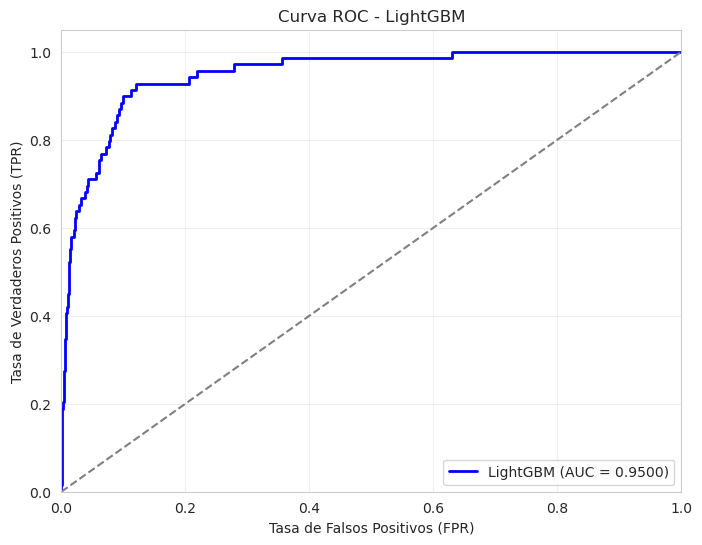

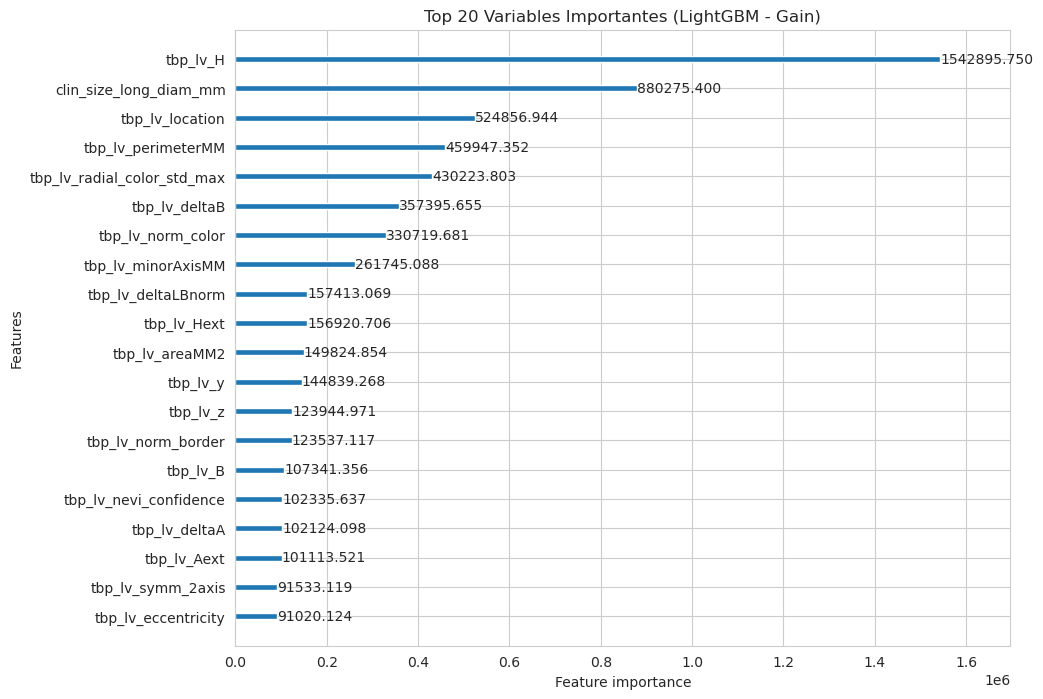

In [9]:
# 4.3 EVALUACIÓN (AUC & ROC)
# ------------------------------------------------------------------------------

# 1. Generar predicciones (Probabilidades)
# predict_proba devuelve [prob_clase_0, prob_clase_1], cogemos la columna 1
y_pred_val_lgbm = model_lgbm.predict_proba(X_val_lgb)[:, 1]

# 2. Calcular métrica AUC
auc_lgbm = roc_auc_score(y_val, y_pred_val_lgbm)
print(f"🏆 LightGBM Validation AUC: {auc_lgbm:.5f}")

# 3. Gráfica Curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_val_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'LightGBM (AUC = {auc_lgbm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Línea base aleatoria
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - LightGBM')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Importancia de Variables (Feature Importance)
# Esto es vital para la sección de "Explainability" de tu presentación
lgb.plot_importance(model_lgbm, max_num_features=20, importance_type='gain', figsize=(10, 8), title='Top 20 Variables Importantes (LightGBM - Gain)')
plt.show()

🔮 Generando predicciones para el conjunto de TEST (100 muestras)...
✅ Predicciones calculadas y almacenadas en la variable 'preds_test_lgbm'.


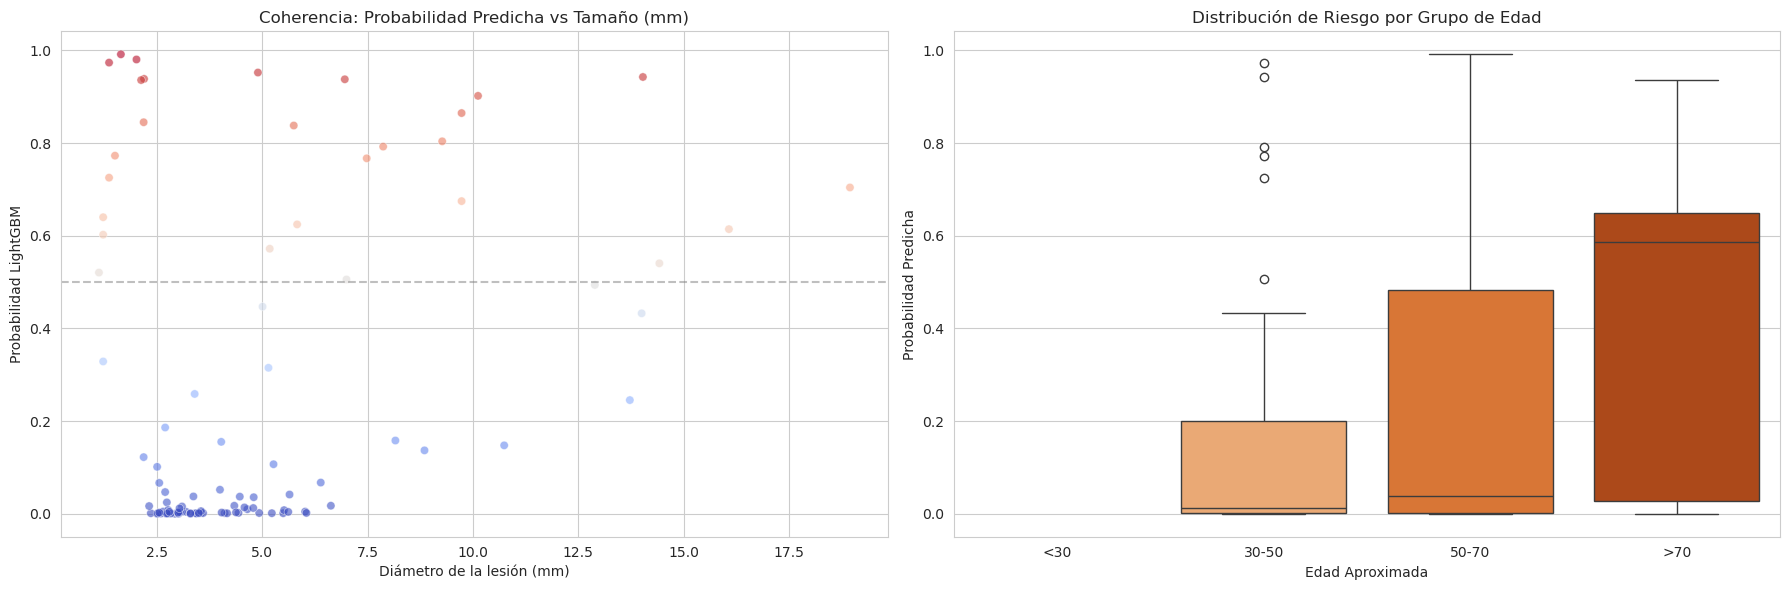


🚨 TOP 10 Casos más sospechosos detectados por LightGBM en Test:


,isic_id,predicted_prob,age_approx,sex,anatom_site_general,clin_size_long_diam_mm
61,ISIC_5068210,0.991456,65.000000,male,head/neck,1.650000
14,ISIC_1705108,0.980306,55.000000,male,anterior torso,2.020000
93,ISIC_7235721,0.973519,50.000000,female,posterior torso,1.370000
69,ISIC_7800702,0.952104,65.000000,male,head/neck,4.900000
43,ISIC_2364514,0.942541,50.000000,male,upper extremity,14.030000
46,ISIC_9152373,0.938445,70.000000,male,upper extremity,2.200000
59,ISIC_0528190,0.937561,65.000000,male,upper extremity,6.960000
72,ISIC_3955107,0.935864,85.000000,male,posterior torso,2.130000
90,ISIC_3890780,0.901829,65.000000,male,lower extremity,10.120000
27,ISIC_1071408,0.864685,60.000000,nan,anterior torso,9.730000


In [10]:
# 4.4 INFERENCIA EN TEST Y SANITY CHECK CLÍNICO
# ------------------------------------------------------------------------------

print(f"🔮 Generando predicciones para el conjunto de TEST ({len(X_test_lgb)} muestras)...")

# 1. GENERAR PREDICCIONES (CRÍTICO: Esto se usará en el Ensemble final)
preds_test_lgbm = model_lgbm.predict_proba(X_test_lgb)[:, 1]
print("✅ Predicciones calculadas y almacenadas en la variable 'preds_test_lgbm'.")

# 2. SANITY CHECK: COHERENCIA BIOLÓGICA
# Verificamos si el modelo respeta reglas médicas básicas (ej. mayor tamaño/edad = mayor riesgo)
# Creamos un dataframe temporal solo para visualización
df_check = X_test_lgb.copy()
df_check['predicted_prob'] = preds_test_lgbm
# Recuperamos el ID original para identificar casos (asumiendo índices alineados)
df_check['isic_id'] = df_test_raw['isic_id']

# Configuración de gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- GRÁFICO A: Probabilidad vs Tamaño de la Lesión ---
# Esperamos correlación positiva: puntos altos (rojos) hacia la derecha
sns.scatterplot(
    data=df_check, 
    x='clin_size_long_diam_mm', 
    y='predicted_prob', 
    hue='predicted_prob', 
    palette='coolwarm', 
    alpha=0.6,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Coherencia: Probabilidad Predicha vs Tamaño (mm)')
axes[0].set_xlabel('Diámetro de la lesión (mm)')
axes[0].set_ylabel('Probabilidad LightGBM')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# --- GRÁFICO B: Probabilidad por Edad (Agrupada) ---
# Esperamos que las cajas suban ligeramente con la edad
# Creamos bins de edad, manejando posibles nulos si los hubiera
df_check['age_group'] = pd.cut(df_check['age_approx'], bins=[0, 30, 50, 70, 90], labels=['<30', '30-50', '50-70', '>70'])
sns.boxplot(
    data=df_check,
    x='age_group',
    y='predicted_prob',
    palette='Oranges',
    ax=axes[1]
)
axes[1].set_title('Distribución de Riesgo por Grupo de Edad')
axes[1].set_xlabel('Edad Aproximada')
axes[1].set_ylabel('Probabilidad Predicha')

plt.tight_layout()
plt.show()

# --- TABLA: TOP 10 CASOS MÁS SOSPECHOSOS ---
print("\n🚨 TOP 10 Casos más sospechosos detectados por LightGBM en Test:")
top_cols = ['isic_id', 'predicted_prob', 'age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm']
top_suspicious = df_check.sort_values(by='predicted_prob', ascending=False).head(10)

# Mostramos la tabla con gradiente de color para destacar probabilidades altas
display(top_suspicious[top_cols].style.background_gradient(subset=['predicted_prob'], cmap='Reds'))

## Modelo 2: CatBoost

In [11]:
# 5.1 PREPARACIÓN DE DATOS PARA CATBOOST
# ------------------------------------------------------------------------------

# Hacemos copias para el preprocesamiento específico de CatBoost
X_train_cat = X_train.copy()
X_val_cat   = X_val.copy()
X_test_cat  = X_test_submission.copy()

# Rellenar nulos categóricos con "Missing"
# CatBoost maneja nulos numéricos automáticamente, pero prefiere strings explícitos en categorías
for col in cat_features:
    X_train_cat[col] = X_train_cat[col].fillna("Missing").astype(str)
    X_val_cat[col]   = X_val_cat[col].fillna("Missing").astype(str)
    X_test_cat[col]  = X_test_cat[col].fillna("Missing").astype(str)

print("✅ Datos preparados para CatBoost (Nulos categóricos imputados como 'Missing').")

✅ Datos preparados para CatBoost (Nulos categóricos imputados como 'Missing').


In [12]:
# 5.2 ENTRENAMIENTO DEL MODELO
# ------------------------------------------------------------------------------

print("🐱 Entrenando CatBoost...")

# Configuración
cat_params = {
    'iterations': 2000,        # Máximo de árboles
    'learning_rate': 0.03,     # Velocidad de aprendizaje (lenta y segura)
    'depth': 6,                # Profundidad estándar
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',      # Optimizamos AUC directamente
    'auto_class_weights': 'Balanced', # ¡CRÍTICO! Manejo del desbalanceo
    'random_seed': SEED,
    'verbose': 200,            # Imprimir cada 200 iteraciones
    'allow_writing_files': False # No generar archivos temporales en disco
}

# Instanciar
model_cat = CatBoostClassifier(**cat_params)

# Entrenar
# Nota: Pasamos 'cat_features' para que use su algoritmo especial
model_cat.fit(
    X_train_cat, y_train,
    eval_set=(X_val_cat, y_val),
    cat_features=cat_features,
    early_stopping_rounds=100,
    plot=False
)

print("\n✅ Entrenamiento CatBoost finalizado.")

🐱 Entrenando CatBoost...
0:	test: 0.8311024	best: 0.8311024 (0)	total: 152ms	remaining: 5m 4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9411491788
bestIteration = 41

Shrink model to first 42 iterations.

✅ Entrenamiento CatBoost finalizado.


📊 Evaluando CatBoost en VALIDACIÓN (80192 muestras)...
🏆 CatBoost Validation AUC: 0.94115
   (Comparativa LightGBM AUC: 0.95002)


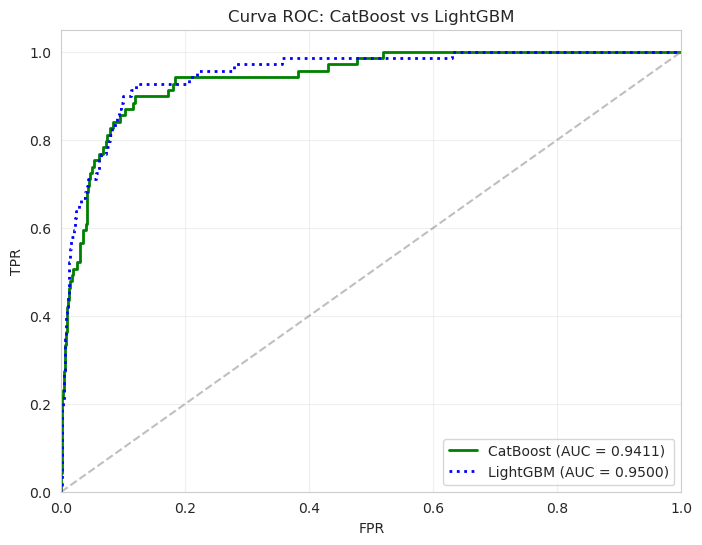

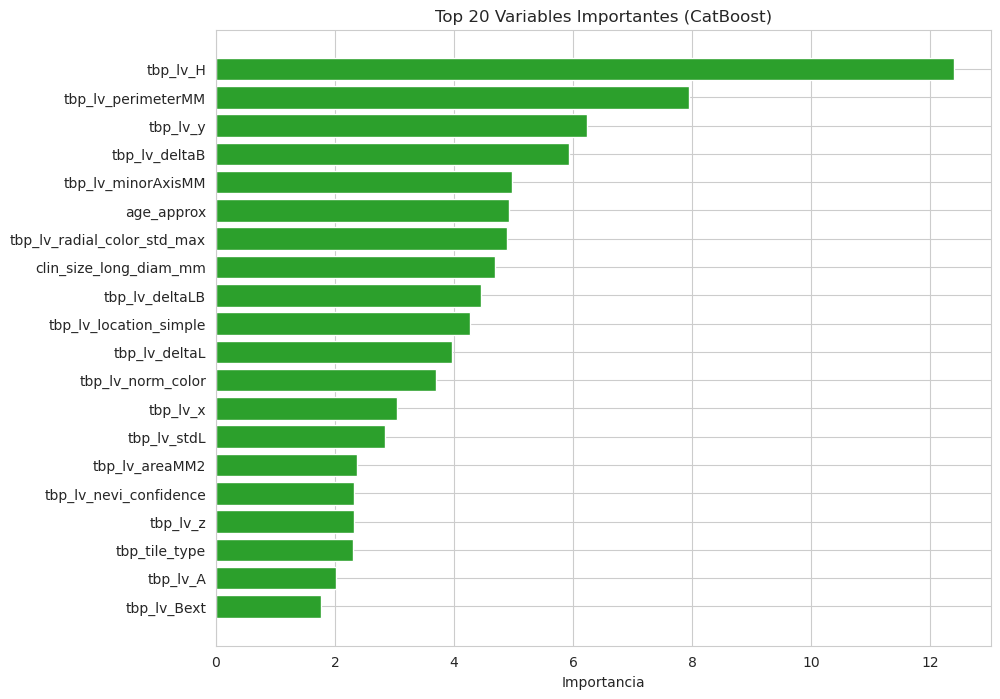

In [13]:
# 5.3 EVALUACIÓN (AUC & FEATURE IMPORTANCE)
# ------------------------------------------------------------------------------

print(f"📊 Evaluando CatBoost en VALIDACIÓN ({len(X_val_cat)} muestras)...")

# 1. Predicciones
y_pred_val_cat = model_cat.predict_proba(X_val_cat)[:, 1]

# 2. AUC
auc_cat = roc_auc_score(y_val, y_pred_val_cat)
print(f"🏆 CatBoost Validation AUC: {auc_cat:.5f}")
print(f"   (Comparativa LightGBM AUC: {auc_lgbm:.5f})")

# 3. Curva ROC Comparativa
fpr_cat, tpr_cat, _ = roc_curve(y_val, y_pred_val_cat)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_pred_val_lgbm) # Recuperamos el anterior

plt.figure(figsize=(8, 6))
plt.plot(fpr_cat, tpr_cat, color='green', lw=2, label=f'CatBoost (AUC = {auc_cat:.4f})')
plt.plot(fpr_lgb, tpr_lgb, color='blue', linestyle=':', lw=2, label=f'LightGBM (AUC = {auc_lgbm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC: CatBoost vs LightGBM')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Feature Importance (Estilo CatBoost)
feature_importance = model_cat.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-20:] # Top 20

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='#2ca02c')
plt.yticks(range(len(sorted_idx)), np.array(X_train_cat.columns)[sorted_idx])
plt.title('Top 20 Variables Importantes (CatBoost)')
plt.xlabel('Importancia')
plt.show()

🔮 Generando predicciones CatBoost para TEST (100 muestras)...
✅ Predicciones calculadas y almacenadas en 'preds_test_cat'.


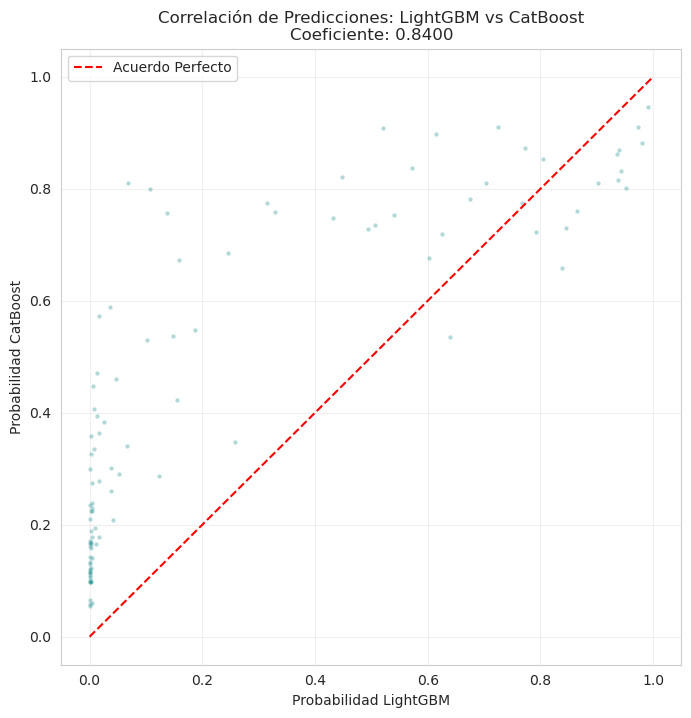

💡 Interpretación: Una correlación de 0.8400 indica que los modelos son
   bastante diferentes. El ensemble podría dar grandes saltos de mejora.


In [14]:
# 5.4 INFERENCIA EN TEST Y CHEQUEO DE CORRELACIÓN
# ------------------------------------------------------------------------------

print(f"🔮 Generando predicciones CatBoost para TEST ({len(X_test_cat)} muestras)...")

# 1. Generar predicciones
preds_test_cat = model_cat.predict_proba(X_test_cat)[:, 1]
print("✅ Predicciones calculadas y almacenadas en 'preds_test_cat'.")

# 2. SANITY CHECK: CORRELACIÓN ENTRE MODELOS
# ¿Están de acuerdo LightGBM y CatBoost?
plt.figure(figsize=(8, 8))
sns.scatterplot(x=preds_test_lgbm, y=preds_test_cat, alpha=0.3, color='teal', s=10)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Acuerdo Perfecto')

# Calculamos correlación de Pearson
correlation = np.corrcoef(preds_test_lgbm, preds_test_cat)[0, 1]

plt.title(f'Correlación de Predicciones: LightGBM vs CatBoost\nCoeficiente: {correlation:.4f}')
plt.xlabel('Probabilidad LightGBM')
plt.ylabel('Probabilidad CatBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"💡 Interpretación: Una correlación de {correlation:.4f} indica que los modelos son")
if correlation > 0.98:
    print("   muy similares. El ensemble aportará estabilidad pero poca ganancia extra.")
elif correlation > 0.85:
    print("   similares pero diversos. ¡IDEAL para ensemble!")
else:
    print("   bastante diferentes. El ensemble podría dar grandes saltos de mejora.")

## Modelo 3: MLP

In [15]:
# 6.1 PIPELINE DE PREPROCESAMIENTO (SKLEARN)
# ------------------------------------------------------------------------------

print("🔧 Preparando Pipeline de transformación para la Red Neuronal...")

# 1. Definir transformadores
# Numéricos: Imputar nulos -> Escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categóricos: Imputar nulos -> One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse=False para tensores densos
])

# 2. Combinar en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    verbose_feature_names_out=False
)

# 3. Aplicar transformaciones
# ¡IMPORTANTE!: Fit solo en TRAIN. Transform en Val y Test.
# Esto evita el "Data Leakage" del escalado.
X_train_mlp = preprocessor.fit_transform(X_train)
X_val_mlp   = preprocessor.transform(X_val)
X_test_mlp  = preprocessor.transform(X_test_submission)

print(f"✅ Datos transformados.")
print(f"   Dimensiones entrada original: {X_train.shape[1]}")
print(f"   Dimensiones entrada MLP (post One-Hot): {X_train_mlp.shape[1]}")

🔧 Preparando Pipeline de transformación para la Red Neuronal...


✅ Datos transformados.
   Dimensiones entrada original: 39
   Dimensiones entrada MLP (post One-Hot): 74


In [16]:
# 6.2 DATASETS Y DATALOADERS (PYTORCH)
# ------------------------------------------------------------------------------

class TabularDataset(Dataset):
    def __init__(self, X_data, y_data=None):
        self.X = torch.FloatTensor(X_data)
        if y_data is not None:
            # Unsqueeze para convertir [batch] a [batch, 1]
            self.y = torch.FloatTensor(y_data.values).unsqueeze(1) 
        else:
            self.y = None
            
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

# Crear Datasets
train_dataset = TabularDataset(X_train_mlp, y_train)
val_dataset   = TabularDataset(X_val_mlp, y_val)
test_dataset  = TabularDataset(X_test_mlp) # Sin target

# Crear Dataloaders
BATCH_SIZE = 1024 # Batch grande para tabular suele ser estable

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False)

print(f"✅ Dataloaders listos. Batches de entrenamiento: {len(train_loader)}")

✅ Dataloaders listos. Batches de entrenamiento: 314


In [17]:
# 6.3 ARQUITECTURA DEL MODELO (SIMPLE MLP)
# ------------------------------------------------------------------------------

class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        
        # Capa 1: Entrada -> 256
        self.layer1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        
        # Capa 2: 256 -> 128
        self.layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        
        # Capa 3: 128 -> 64
        self.layer3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        
        # Salida: 64 -> 1
        self.output = nn.Linear(64, 1)
        
        # Funciones de activación y regularización
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3) # 30% de neuronas apagadas
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.layer3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        # Devolvemos logits (sin sigmoide, eso va en la Loss Function)
        return self.output(x)

# Inicializar modelo
input_dim = X_train_mlp.shape[1]
model_mlp = TabularMLP(input_dim).to(DEVICE)

print(f"🧠 Modelo MLP creado en {DEVICE}. Entradas: {input_dim}")

# ------------------------------------------------------------------------------
# CONFIGURACIÓN DE ENTRENAMIENTO (Loss & Optimizer)
# ------------------------------------------------------------------------------

# Cálculo del peso para el desbalanceo (Negativos / Positivos)
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor([num_neg / num_pos]).to(DEVICE)

print(f"⚖️ Peso de clase positiva (pos_weight): {pos_weight.item():.2f}")

# Loss Function con peso
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizador y Scheduler
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3, verbose=True)

🧠 Modelo MLP creado en cuda. Entradas: 74
⚖️ Peso de clase positiva (pos_weight): 1169.68


In [18]:
# 6.4 BUCLE DE ENTRENAMIENTO
# ------------------------------------------------------------------------------

EPOCHS = 25
best_auc_mlp = 0.0
best_model_state = None
patience = 5
patience_counter = 0

print(f"🚀 Iniciando entrenamiento por {EPOCHS} épocas...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model_mlp.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model_mlp(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION ---
    model_mlp.eval()
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            logits = model_mlp(X_batch)
            probs = torch.sigmoid(logits) # Logits -> Probabilidad
            
            val_preds.extend(probs.cpu().numpy())
            val_targets.extend(y_batch.numpy())
            
    val_auc = roc_auc_score(val_targets, val_preds)
    
    # --- LOGGING & SAVING ---
    # Scheduler step basado en AUC
    scheduler.step(val_auc)
    
    print(f"Epoch {epoch+1:02d} | Loss: {avg_train_loss:.4f} | Val AUC: {val_auc:.5f}", end="")
    
    if val_auc > best_auc_mlp:
        best_auc_mlp = val_auc
        best_model_state = model_mlp.state_dict()
        patience_counter = 0
        print(" 🏆 Mejor Modelo!")
    else:
        patience_counter += 1
        print("")
        
    if patience_counter >= patience:
        print(f"🛑 Early Stopping activado en época {epoch+1}")
        break

# Cargar el mejor modelo entrenado
if best_model_state is not None:
    model_mlp.load_state_dict(best_model_state)
    print(f"\n✅ Entrenamiento finalizado. Mejor AUC MLP: {best_auc_mlp:.5f}")

🚀 Iniciando entrenamiento por 25 épocas...
Epoch 01 | Loss: 0.9651 | Val AUC: 0.92885 🏆 Mejor Modelo!
Epoch 02 | Loss: 0.7647 | Val AUC: 0.93390 🏆 Mejor Modelo!
Epoch 03 | Loss: 0.6568 | Val AUC: 0.94071 🏆 Mejor Modelo!
Epoch 04 | Loss: 0.6054 | Val AUC: 0.94434 🏆 Mejor Modelo!
Epoch 05 | Loss: 0.5374 | Val AUC: 0.93714
Epoch 06 | Loss: 0.5790 | Val AUC: 0.94614 🏆 Mejor Modelo!
Epoch 07 | Loss: 0.5259 | Val AUC: 0.93602
Epoch 08 | Loss: 0.4863 | Val AUC: 0.94337
Epoch 09 | Loss: 0.4596 | Val AUC: 0.94730 🏆 Mejor Modelo!
Epoch 10 | Loss: 0.4518 | Val AUC: 0.94703
Epoch 11 | Loss: 0.4432 | Val AUC: 0.93818
Epoch 12 | Loss: 0.4408 | Val AUC: 0.94114
Epoch 13 | Loss: 0.4441 | Val AUC: 0.94080
Epoch 14 | Loss: 0.4281 | Val AUC: 0.94345
🛑 Early Stopping activado en época 14

✅ Entrenamiento finalizado. Mejor AUC MLP: 0.94730


🔮 Generando predicciones MLP para TEST...
✅ Predicciones MLP calculadas.


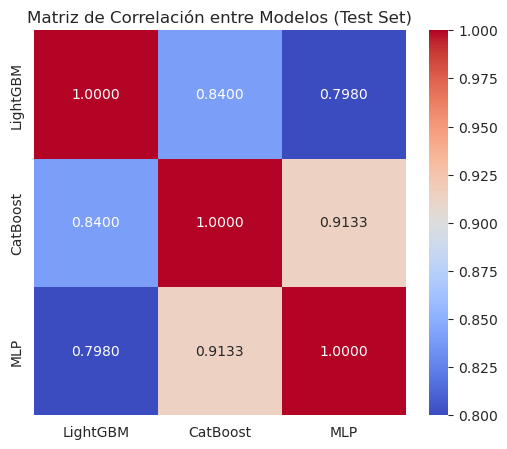

💡 Nota: Si la correlación del MLP con los árboles es menor que entre los árboles entre sí,
   el MLP está aportando información única y valiosa para el Stacking.


In [19]:
# 6.5 INFERENCIA EN TEST Y COMPARATIVA FINAL
# ------------------------------------------------------------------------------

print(f"🔮 Generando predicciones MLP para TEST...")

model_mlp.eval()
preds_test_mlp = []

with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model_mlp(X_batch)
        probs = torch.sigmoid(logits)
        preds_test_mlp.extend(probs.cpu().numpy().flatten())

preds_test_mlp = np.array(preds_test_mlp)
print("✅ Predicciones MLP calculadas.")

# --- MATRIZ DE CORRELACIÓN DE PREDICCIONES ---
# Verificamos la diversidad del ensemble
df_corr = pd.DataFrame({
    'LightGBM': preds_test_lgbm,
    'CatBoost': preds_test_cat,
    'MLP': preds_test_mlp
})

plt.figure(figsize=(6, 5))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".4f", vmin=0.8, vmax=1.0)
plt.title('Matriz de Correlación entre Modelos (Test Set)')
plt.show()

print("💡 Nota: Si la correlación del MLP con los árboles es menor que entre los árboles entre sí,")
print("   el MLP está aportando información única y valiosa para el Stacking.")

## Comparativa y ensemble


🏆 CLASIFICACIÓN FINAL (VALIDACIÓN):


,Modelo,AUC Val
0,LightGBM,0.950017
2,MLP (PyTorch),0.947296
1,CatBoost,0.941149


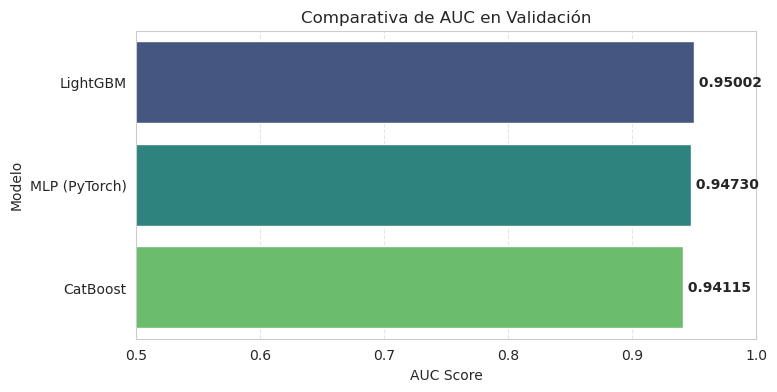

In [20]:
# 7.1 COMPARATIVA DE RENDIMIENTO (AUC EN VALIDACIÓN)
# ------------------------------------------------------------------------------

# Crear DataFrame de resultados
results_df = pd.DataFrame({
    'Modelo': ['LightGBM', 'CatBoost', 'MLP (PyTorch)'],
    'AUC Val': [auc_lgbm, auc_cat, best_auc_mlp]
}).sort_values(by='AUC Val', ascending=False)

print("\n🏆 CLASIFICACIÓN FINAL (VALIDACIÓN):")
display(results_df)

# Gráfico de barras
plt.figure(figsize=(8, 4))
sns.barplot(x='AUC Val', y='Modelo', data=results_df, palette='viridis')
plt.xlim(0.5, 1.0) # Ajustar escala para ver diferencias sutiles
plt.title('Comparativa de AUC en Validación')
plt.xlabel('AUC Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
for index, value in enumerate(results_df['AUC Val']):
    plt.text(value, index, f' {value:.5f}', va='center', fontweight='bold')
plt.show()

⚖️ Pesos del Ensemble: LGBM=0.4, CatBoost=0.4, MLP=0.2
🔄 Recalculando predicciones de validación para el MLP...

🌟 AUC FINAL ENSEMBLE (VALIDACIÓN): 0.95126
   (Mejor modelo individual: 0.95002)


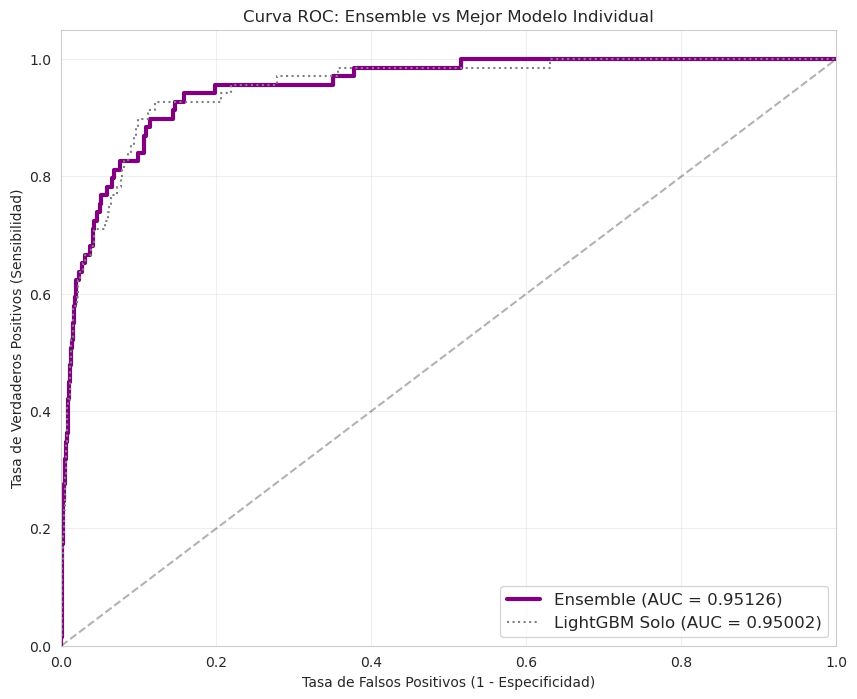

✅ CONCLUSIÓN: El Ensemble MEJORA el resultado individual. ¡Vale la pena usarlo!


In [22]:
# 7.2 CÁLCULO DEL ENSEMBLE (TEST SET)
# ------------------------------------------------------------------------------

# Definir pesos (ajustables según rendimiento en validación)
W_LGBM = 0.4
W_CAT  = 0.4
W_MLP  = 0.2

print(f"⚖️ Pesos del Ensemble: LGBM={W_LGBM}, CatBoost={W_CAT}, MLP={W_MLP}")

# Calcular predicción ponderada
preds_test_ensemble = (preds_test_lgbm * W_LGBM) + \
                      (preds_test_cat * W_CAT) + \
                      (preds_test_mlp * W_MLP)

## ------------------------------------------------------------------------------
# 7.3 VALIDACIÓN DEL ENSEMBLE Y CURVA ROC
# ------------------------------------------------------------------------------

print("🔄 Recalculando predicciones de validación para el MLP...")
model_mlp.eval()
y_pred_val_mlp = []
with torch.no_grad():
    for X_batch, _ in val_loader: # Solo necesitamos X
        X_batch = X_batch.to(DEVICE)
        logits = model_mlp(X_batch)
        probs = torch.sigmoid(logits)
        y_pred_val_mlp.extend(probs.cpu().numpy().flatten())
y_pred_val_mlp = np.array(y_pred_val_mlp)

# 1. CALCULAR ENSEMBLE EN VALIDACIÓN
# Usamos los mismos pesos que definimos antes
y_pred_val_ensemble = (y_pred_val_lgbm * W_LGBM) + \
                      (y_pred_val_cat * W_CAT) + \
                      (y_pred_val_mlp * W_MLP)

# 2. CALCULAR AUC DEL ENSEMBLE
auc_ensemble_val = roc_auc_score(y_val, y_pred_val_ensemble)
print(f"\n🌟 AUC FINAL ENSEMBLE (VALIDACIÓN): {auc_ensemble_val:.5f}")
print(f"   (Mejor modelo individual: {max(auc_lgbm, auc_cat, best_auc_mlp):.5f})")

# 3. GRÁFICO ROC COMPARATIVO
fpr_ens, tpr_ens, _ = roc_curve(y_val, y_pred_val_ensemble)
fpr_best, tpr_best, _ = roc_curve(y_val, y_pred_val_lgbm) # Asumimos LGBM como referencia

plt.figure(figsize=(10, 8))
plt.plot(fpr_ens, tpr_ens, color='purple', lw=3, label=f'Ensemble (AUC = {auc_ensemble_val:.5f})')
plt.plot(fpr_best, tpr_best, color='gray', linestyle=':', label=f'LightGBM Solo (AUC = {auc_lgbm:.5f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC: Ensemble vs Mejor Modelo Individual')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Interpretación
if auc_ensemble_val > max(auc_lgbm, auc_cat, best_auc_mlp):
    print("✅ CONCLUSIÓN: El Ensemble MEJORA el resultado individual. ¡Vale la pena usarlo!")
else:
    print("⚠️ CONCLUSIÓN: El Ensemble no supera claramente al mejor modelo individual.")

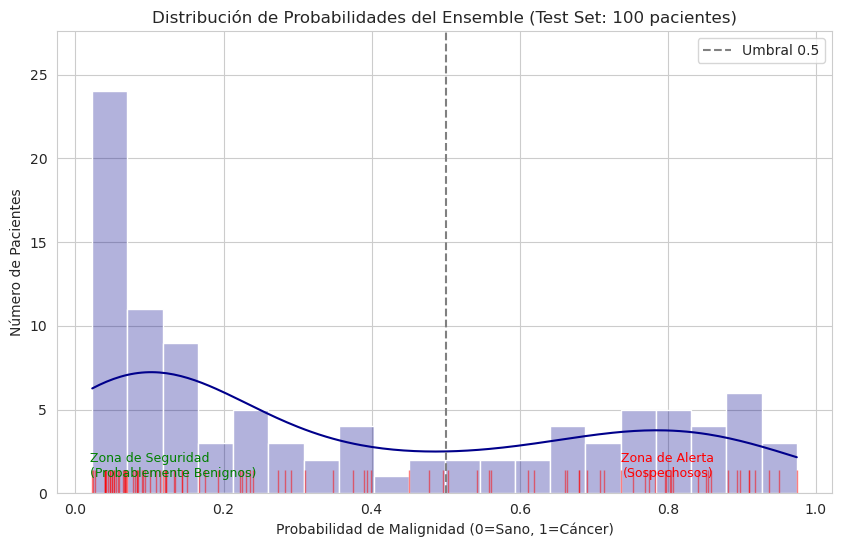

In [ ]:
# 7.4 VISUALIZACIÓN MEJORADA: PREDICCIONES DEL TEST
# ------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

# 1. Histograma con menos bins (para 100 datos, 20 bins es suficiente)
sns.histplot(
    preds_test_ensemble, 
    bins=20, 
    kde=True,          # Añade la línea curva suave
    color='darkblue', 
    alpha=0.3,
    stat='count'
)

# 2. Rug Plot: Dibuja una rayita por cada paciente
# Esto permite ver exactamente dónde están los 100 puntos
sns.rugplot(preds_test_ensemble, color='red', height=0.05, alpha=0.5)

plt.title('Distribución de Probabilidades del Ensemble (Test Set: 100 pacientes)')
plt.xlabel('Probabilidad de Malignidad (0=Sano, 1=Cáncer)')
plt.ylabel('Número de Pacientes')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')

# Añadir anotaciones
plt.text(0.02, 1, 'Zona de Seguridad\n(Probablemente Benignos)', color='green', fontsize=9)
plt.text(0.80, 1, 'Zona de Alerta\n(Sospechosos)', color='red', fontsize=9, ha='center')

plt.legend()
plt.show()

## Generación de archivos para el ensemble final

In [25]:
# ------------------------------------------------------------------------------
# 8. GENERACIÓN DE ARCHIVOS DE SUBMISSION (ORGANIZADOS)
# ------------------------------------------------------------------------------

# 1. Configuración de Carpeta y Prefijos
OUTPUT_DIR = "predictions"  # Nombre de la carpeta de salida
PREFIX = "metaonly_"        # Prefijo para identificar estos modelos

# Crear carpeta si no existe
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📂 Carpeta creada: {OUTPUT_DIR}/")
else:
    print(f"📂 Usando carpeta existente: {OUTPUT_DIR}/")

print("💾 Guardando archivos...")

# Recuperamos los IDs del test
test_ids = df_test_raw['isic_id']

# --- 1. Submission LightGBM ---
filename_lgbm = f"{PREFIX}submission_lgbm.csv"
path_lgbm = os.path.join(OUTPUT_DIR, filename_lgbm)

df_sub_lgbm = pd.DataFrame({'isic_id': test_ids, 'target': preds_test_lgbm})
df_sub_lgbm.to_csv(path_lgbm, index=False)
print(f"✅ [1/4] Guardado: {path_lgbm}")

# --- 2. Submission CatBoost ---
filename_cat = f"{PREFIX}submission_catboost.csv"
path_cat = os.path.join(OUTPUT_DIR, filename_cat)

df_sub_cat = pd.DataFrame({'isic_id': test_ids, 'target': preds_test_cat})
df_sub_cat.to_csv(path_cat, index=False)
print(f"✅ [2/4] Guardado: {path_cat}")

# --- 3. Submission MLP ---
filename_mlp = f"{PREFIX}submission_mlp.csv"
path_mlp = os.path.join(OUTPUT_DIR, filename_mlp)

df_sub_mlp = pd.DataFrame({'isic_id': test_ids, 'target': preds_test_mlp})
df_sub_mlp.to_csv(path_mlp, index=False)
print(f"✅ [3/4] Guardado: {path_mlp}")

# --- 4. Submission ENSEMBLE (La principal) ---
filename_ens = f"{PREFIX}submission_ensemble.csv"
path_ens = os.path.join(OUTPUT_DIR, filename_ens)

df_sub_ensemble = pd.DataFrame({'isic_id': test_ids, 'target': preds_test_ensemble})
df_sub_ensemble.to_csv(path_ens, index=False)
print(f"✅ [4/4] Guardado: {path_ens}")

# --- EXTRA: Predicciones crudas para Stacking Futuro ---
filename_all = f"{PREFIX}model_predictions_full.csv"
path_all = os.path.join(OUTPUT_DIR, filename_all)

df_all_preds = pd.DataFrame({
    'isic_id': test_ids,
    'lgbm_prob': preds_test_lgbm,
    'catboost_prob': preds_test_cat,
    'mlp_prob': preds_test_mlp,
    'ensemble_meta_prob': preds_test_ensemble
})
df_all_preds.to_csv(path_all, index=False)
print(f"\n💾 EXTRA: '{path_all}' guardado (Úsalo para el Stacking con imágenes).")

📂 Carpeta creada: predictions/
💾 Guardando archivos...
✅ [1/4] Guardado: predictions/metaonly_submission_lgbm.csv
✅ [2/4] Guardado: predictions/metaonly_submission_catboost.csv
✅ [3/4] Guardado: predictions/metaonly_submission_mlp.csv
✅ [4/4] Guardado: predictions/metaonly_submission_ensemble.csv

💾 EXTRA: 'predictions/metaonly_model_predictions_full.csv' guardado (Úsalo para el Stacking con imágenes).
